## Visualize the 3 fidelities together

In [1]:
# ## Load and aggregate the three normalized metrics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/lka_vam")

MARGINAL_PATH = FIDELITY_DIR / "emd_gen_true_normalized.csv"
BIVARIATE_PATH = FIDELITY_DIR / "corrdiff_gen_true_normalized.csv"
JOINT_PATH = FIDELITY_DIR / "joint_emd_gen_true_normalized.csv"

marginal_df = pd.read_csv(MARGINAL_PATH)
bivariate_df = pd.read_csv(BIVARIATE_PATH)
joint_df = pd.read_csv(JOINT_PATH)

print("marginal_df:", marginal_df.shape)
print("bivariate_df:", bivariate_df.shape)
print("joint_df:", joint_df.shape)

display(marginal_df.head())
display(bivariate_df.head())
display(joint_df.head())

marginal_df: (1074, 10)
bivariate_df: (2685, 14)
joint_df: (179, 11)


,model,seed,adm1,variable,emd_distance,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Central,education_score,0.027851,0.004593,0.162308,0.157716,0.147469,0.147469
1,cNF,1,Central,log_income,0.058058,0.022513,0.608335,0.585822,0.060674,0.060674
2,cNF,1,Central,space_per_person,0.054669,0.020460,0.412065,0.391605,0.087357,0.087357
3,cNF,1,Central,FES,0.007270,0.005950,0.115454,0.109504,0.012059,0.012059
4,cNF,1,Central,FCS,1.215890,0.375782,13.451259,13.075477,0.064251,0.064251


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff,corrdiff_ub,corrdiff_lb,denom,corrdiff_norm_raw,corrdiff_norm
0,cNF,1,Central,education_score,log_income,education_score__log_income,0.434822,0.413783,0.021039,0.021314,0.406130,0.384816,-0.000714,0.000000
1,cNF,1,Central,education_score,space_per_person,education_score__space_per_person,-0.118365,-0.151085,0.032720,0.021782,0.127116,0.105335,0.103839,0.103839
2,cNF,1,Central,education_score,FES,education_score__FES,-0.142941,-0.093366,0.049575,0.013418,0.155206,0.141788,0.255005,0.255005
3,cNF,1,Central,education_score,FCS,education_score__FCS,0.309211,0.192850,0.116361,0.002774,0.308588,0.305815,0.371425,0.371425
4,cNF,1,Central,education_score,rCSI,education_score__rCSI,-0.178791,-0.151451,0.027339,0.005851,0.187050,0.181199,0.118590,0.118590


,model,seed,adm1,joint_emd,n_real,n_syn,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Central,0.842929,1833,1833,0.369761,1.037704,0.667943,0.708395,0.708395
1,cNF,1,Eastern,0.939766,1711,1711,0.391495,1.135545,0.744050,0.736874,0.736874
2,cNF,1,North Central,0.966461,1185,1185,0.405948,1.181453,0.775505,0.722772,0.722772
3,cNF,1,North Western,0.941148,1197,1197,0.420666,1.073062,0.652396,0.797801,0.797801
4,cNF,1,Northern,0.855875,2769,2769,0.358779,0.988544,0.629765,0.789335,0.789335


In [3]:
# Average marginal over variables for each (model, seed, adm1)
marginal_avg = (
    marginal_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        marginal_norm=("emd_norm", "mean")
    )
)

# Average bivariate over pairs for each (model, seed, adm1)
bivariate_avg = (
    bivariate_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        bivariate_norm=("corrdiff_norm", "mean")
    )
)

# Joint is already one value per (model, seed, adm1)
joint_avg = (
    joint_df[["model", "seed", "adm1", "emd_norm"]]
    .rename(columns={"emd_norm": "joint_norm"})
    .copy()
)

display(marginal_avg.head())
display(bivariate_avg.head())
display(joint_avg.head())

,model,seed,adm1,marginal_norm
0,CTGAN,1,Central,0.336337
1,CTGAN,1,Eastern,0.325814
2,CTGAN,1,North Central,0.388376
3,CTGAN,1,North Western,0.381536
4,CTGAN,1,Northern,0.308019


,model,seed,adm1,bivariate_norm
0,CTGAN,1,Central,0.635296
1,CTGAN,1,Eastern,0.899793
2,CTGAN,1,North Central,0.922596
3,CTGAN,1,North Western,0.634966
4,CTGAN,1,Northern,0.696677


,model,seed,adm1,joint_norm
0,cNF,1,Central,0.708395
1,cNF,1,Eastern,0.736874
2,cNF,1,North Central,0.722772
3,cNF,1,North Western,0.797801
4,cNF,1,Northern,0.789335


In [4]:
# Merge the 3 metrics so each row is one (model, seed, adm1)
metrics_3way = (
    marginal_avg
    .merge(bivariate_avg, on=["model", "seed", "adm1"], how="inner")
    .merge(joint_avg, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("metrics_3way shape:", metrics_3way.shape)
display(metrics_3way.head())

metrics_3way shape: (179, 6)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Central,0.336337,0.635296,1.0
1,CTGAN,1,Eastern,0.325814,0.899793,1.0
2,CTGAN,1,North Central,0.388376,0.922596,1.0
3,CTGAN,1,North Western,0.381536,0.634966,1.0
4,CTGAN,1,Northern,0.308019,0.696677,1.0


In [5]:
# Optional: save merged table
OUT_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
metrics_3way.to_csv(OUT_PATH, index=False)
print(f"Saved merged table to: {OUT_PATH}")

Saved merged table to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_vam/merged_marginal_bivariate_joint_normalized.csv


In [6]:
# ## Prepare radar-plot summary
#
# We want:
# - for each model and seed: average across adm1
# - then across seeds: mean
# - and std based on the adm1-level variability after seed averaging

METRIC_COLS = ["marginal_norm", "bivariate_norm", "joint_norm"]

# Mean over adm1 within each seed
seed_level = (
    metrics_3way
    .groupby(["model", "seed"], as_index=False)[METRIC_COLS]
    .mean()
)

display(seed_level.head())

,model,seed,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,0.309563,0.764386,0.994326
1,CTGAN,2,0.325719,0.731736,1.000000
2,CTGAN,3,0.292078,0.758028,1.000000
3,CTGAN,4,0.388274,0.786425,1.000000
4,CTGAN,5,0.347544,0.812251,1.000000


In [7]:
# Mean and std across seeds for the central line
model_mean_std = (
    seed_level
    .groupby("model", as_index=False)
    .agg(
        marginal_mean=("marginal_norm", "mean"),
        marginal_std_seed=("marginal_norm", "std"),
        bivariate_mean=("bivariate_norm", "mean"),
        bivariate_std_seed=("bivariate_norm", "std"),
        joint_mean=("joint_norm", "mean"),
        joint_std_seed=("joint_norm", "std"),
    )
)

model_mean_std = model_mean_std.fillna(0.0)
display(model_mean_std)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed
0,CTGAN,0.332636,0.037226,0.770565,0.030382,0.998865,0.002538
1,NF,0.097232,0.055718,0.271717,0.092898,0.725915,0.090630
2,TVAE,0.435290,0.071142,0.500330,0.041141,0.999252,0.001673
3,cNF,0.127392,0.031659,0.317848,0.062147,0.784814,0.060291


In [8]:
# Std over adm1:
# first average across seeds for each (model, adm1), then compute std across adm1

adm1_level = (
    metrics_3way
    .groupby(["model", "adm1"], as_index=False)[METRIC_COLS]
    .mean()
)

model_adm1_std = (
    adm1_level
    .groupby("model", as_index=False)
    .agg(
        marginal_std_adm1=("marginal_norm", "std"),
        bivariate_std_adm1=("bivariate_norm", "std"),
        joint_std_adm1=("joint_norm", "std"),
    )
)

model_adm1_std = model_adm1_std.fillna(0.0)
display(model_adm1_std)

,model,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.021264,0.050110,0.003405
1,NF,0.021344,0.046177,0.065780
2,TVAE,0.070469,0.064125,0.002244
3,cNF,0.019817,0.049493,0.053907


In [9]:
# Final table for plotting
radar_df = (
    model_mean_std
    .merge(model_adm1_std, on="model", how="left")
    .fillna(0.0)
)

display(radar_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.332636,0.037226,0.770565,0.030382,0.998865,0.002538,0.021264,0.050110,0.003405
1,NF,0.097232,0.055718,0.271717,0.092898,0.725915,0.090630,0.021344,0.046177,0.065780
2,TVAE,0.435290,0.071142,0.500330,0.041141,0.999252,0.001673,0.070469,0.064125,0.002244
3,cNF,0.127392,0.031659,0.317848,0.062147,0.784814,0.060291,0.019817,0.049493,0.053907


In [10]:
# ## Spider / radar plot

MODEL_ORDER = ["cNF", #"NF", 
"TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in radar_df["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

AXES_LABELS = ["Marginal", "Bivariate", "Joint"]
N_AXES = len(AXES_LABELS)

angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]  # close polygon

In [11]:
def close_vals(vals):
    vals = list(vals)
    return vals + vals[:1]

In [12]:
# Convert normalized errors into normalized fidelity scores
radar_score_df = radar_df.copy()

for col in [
    "marginal_mean", "bivariate_mean", "joint_mean",
]:
    radar_score_df[col] = 1.0 - radar_score_df[col]

display(radar_score_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.667364,0.037226,0.229435,0.030382,0.001135,0.002538,0.021264,0.050110,0.003405
1,NF,0.902768,0.055718,0.728283,0.092898,0.274085,0.090630,0.021344,0.046177,0.065780
2,TVAE,0.564710,0.071142,0.499670,0.041141,0.000748,0.001673,0.070469,0.064125,0.002244
3,cNF,0.872608,0.031659,0.682152,0.062147,0.215186,0.060291,0.019817,0.049493,0.053907


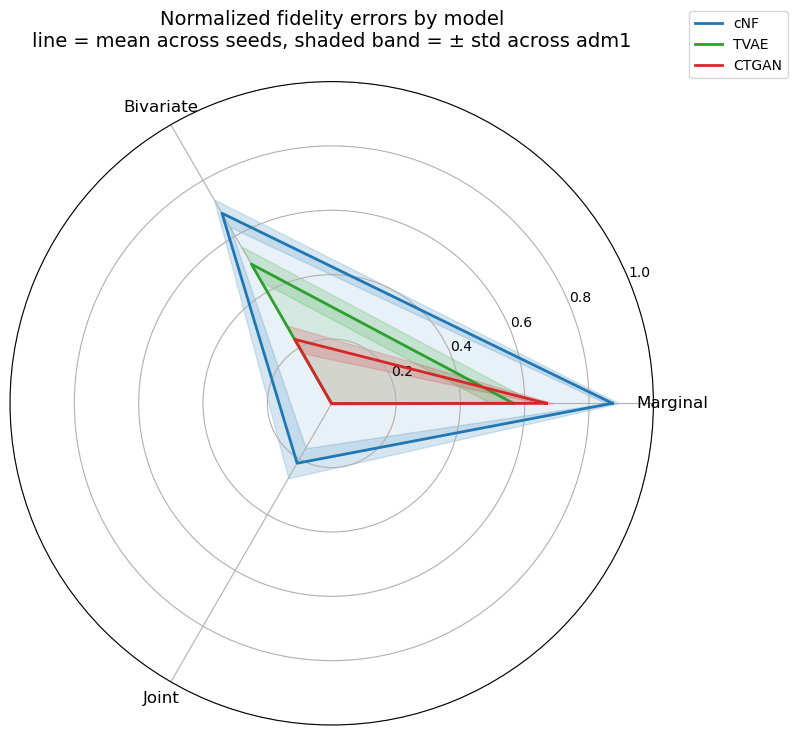

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model in MODEL_ORDER:
    row = radar_score_df.loc[radar_score_df["model"] == model]
    if row.empty:
        continue
    row = row.iloc[0]

    means = [
        row["marginal_mean"],
        row["bivariate_mean"],
        row["joint_mean"],
    ]

    stds_adm1 = [
        row["marginal_std_adm1"],
        row["bivariate_std_adm1"],
        row["joint_std_adm1"],
    ]

    lower = np.clip(np.array(means) - np.array(stds_adm1), 0, 1)
    upper = np.clip(np.array(means) + np.array(stds_adm1), 0, 1)

    means_c = close_vals(means)
    lower_c = close_vals(lower)
    upper_c = close_vals(upper)

    color = MODEL_COLORS.get(model, "gray")

    ax.plot(
        angles,
        means_c,
        color=color,
        linewidth=2,
        label=model,
    )

    ax.fill(
        angles,
        means_c,
        color=color,
        alpha=0.10,
    )

    ax.fill_between(
        angles,
        lower_c,
        upper_c,
        color=color,
        alpha=0.18,
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES_LABELS, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_title(
    "Normalized fidelity errors by model\nline = mean across seeds, shaded band = ± std across adm1",
    pad=25,
    fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.12))

plt.tight_layout()
plt.show()

## Look at originality too

In [14]:
# ## Load fidelity + recall

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/lka_vam")
RECALL_DIR = Path("/data/shared/fsibilla/clean_code/Q0/recall/lka_vam")

FIDELITY_3WAY_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
RECALL_PATH = RECALL_DIR / "recall_gen_true_by_adm1.csv"

fidelity_3way = pd.read_csv(FIDELITY_3WAY_PATH)
recall_df = pd.read_csv(RECALL_PATH)

print("fidelity_3way:", fidelity_3way.shape)
print("recall_df:", recall_df.shape)

display(fidelity_3way.head())
display(recall_df.head())

fidelity_3way: (179, 6)
recall_df: (179, 8)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Central,0.336337,0.635296,1.0
1,CTGAN,1,Eastern,0.325814,0.899793,1.0
2,CTGAN,1,North Central,0.388376,0.922596,1.0
3,CTGAN,1,North Western,0.381536,0.634966,1.0
4,CTGAN,1,Northern,0.308019,0.696677,1.0


,model,seed,adm1,recall,matched_real,n_real,n_syn,radius
0,cNF,1,Central,0.260775,478,1833,1833,0.5
1,cNF,1,Eastern,0.226184,387,1711,1711,0.5
2,cNF,1,North Central,0.249789,296,1185,1185,0.5
3,cNF,1,North Western,0.185464,222,1197,1197,0.5
4,cNF,1,Northern,0.322860,894,2769,2769,0.5


In [16]:
# Average the 3 fidelity metrics into one fidelity score (still an error, so lower is better)
fidelity_3way = fidelity_3way.copy()

fidelity_3way["fidelity_mean"] = fidelity_3way[
    ["marginal_norm", "bivariate_norm", "joint_norm"]
].mean(axis=1)

display(fidelity_3way.head())

,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm,fidelity_mean
0,CTGAN,1,Central,0.336337,0.635296,1.0,0.657211
1,CTGAN,1,Eastern,0.325814,0.899793,1.0,0.741869
2,CTGAN,1,North Central,0.388376,0.922596,1.0,0.770324
3,CTGAN,1,North Western,0.381536,0.634966,1.0,0.672167
4,CTGAN,1,Northern,0.308019,0.696677,1.0,0.668232


In [17]:
# Keep only the columns needed for the merge
fidelity_for_merge = fidelity_3way[
    ["model", "seed", "adm1", "fidelity_mean"]
].copy()

recall_for_merge = recall_df[
    ["model", "seed", "adm1", "recall"]
].copy()

plot_source = (
    fidelity_for_merge
    .merge(recall_for_merge, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("plot_source shape:", plot_source.shape)
display(plot_source.head())

plot_source shape: (179, 5)


,model,seed,adm1,fidelity_mean,recall
0,CTGAN,1,Central,0.657211,0.155483
1,CTGAN,1,Eastern,0.741869,0.191701
2,CTGAN,1,North Central,0.770324,0.259916
3,CTGAN,1,North Western,0.672167,0.147870
4,CTGAN,1,Northern,0.668232,0.220296


In [18]:
# One scatter point per model with x/y std dev error bars
model_summary = (
    plot_source
    .groupby("model", as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        fidelity_mean=("fidelity_mean", "mean"),
        fidelity_std=("fidelity_mean", "std"),
        n_rows=("recall", "count"),
    )
)

model_summary["recall_std"] = model_summary["recall_std"].fillna(0.0)
model_summary["fidelity_std"] = model_summary["fidelity_std"].fillna(0.0)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,CTGAN,0.173778,0.045578,0.700689,0.038677,45
1,NF,0.262448,0.065451,0.364955,0.102569,45
2,TVAE,0.192261,0.087212,0.644263,0.064844,44
3,cNF,0.240897,0.063922,0.410018,0.072542,45


In [19]:
MODEL_ORDER = ["cNF", #"NF",
 "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in model_summary["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    #"NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

model_summary = (
    model_summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,cNF,0.240897,0.063922,0.410018,0.072542,45
1,TVAE,0.192261,0.087212,0.644263,0.064844,44
2,CTGAN,0.173778,0.045578,0.700689,0.038677,45


In [20]:
model_summary_plot = model_summary.copy()
model_summary_plot["fidelity_score"] = 1.0 - model_summary_plot["fidelity_mean"]

display(model_summary_plot)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows,fidelity_score
0,cNF,0.240897,0.063922,0.410018,0.072542,45,0.589982
1,TVAE,0.192261,0.087212,0.644263,0.064844,44,0.355737
2,CTGAN,0.173778,0.045578,0.700689,0.038677,45,0.299311


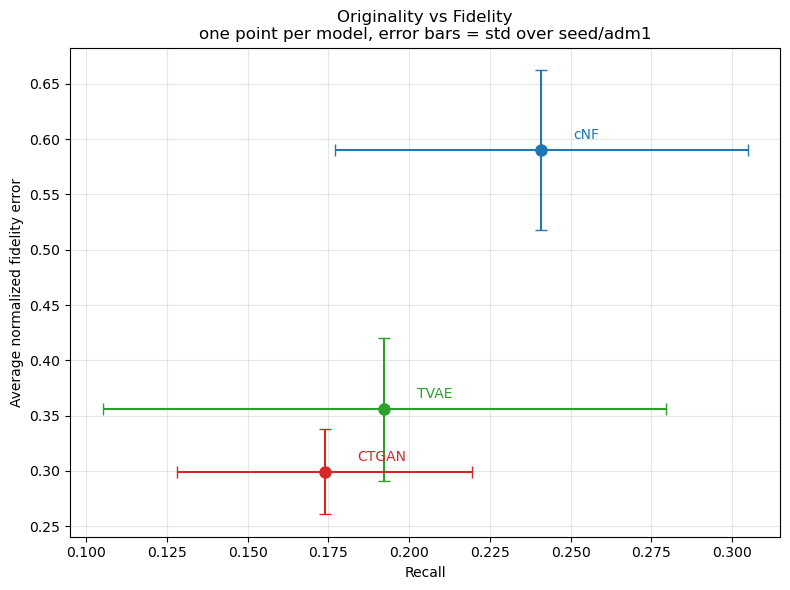

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in model_summary_plot.iterrows():
    model = row["model"]
    x = row["recall_mean"]
    y = row["fidelity_score"]
    xerr = row["recall_std"]
    yerr = row["fidelity_std"]
    color = MODEL_COLORS.get(model, "gray")

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        capsize=4,
        markersize=8,
        color=color,
        ecolor=color,
        elinewidth=1.5,
        label=model,
    )

    ax.text(
        x + 0.01,
        y + 0.01,
        model,
        fontsize=10,
        color=color,
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Average normalized fidelity error")
ax.set_title("Originality vs Fidelity\none point per model, error bars = std over seed/adm1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()